# Dataset "Bank Customer"

## Classification task

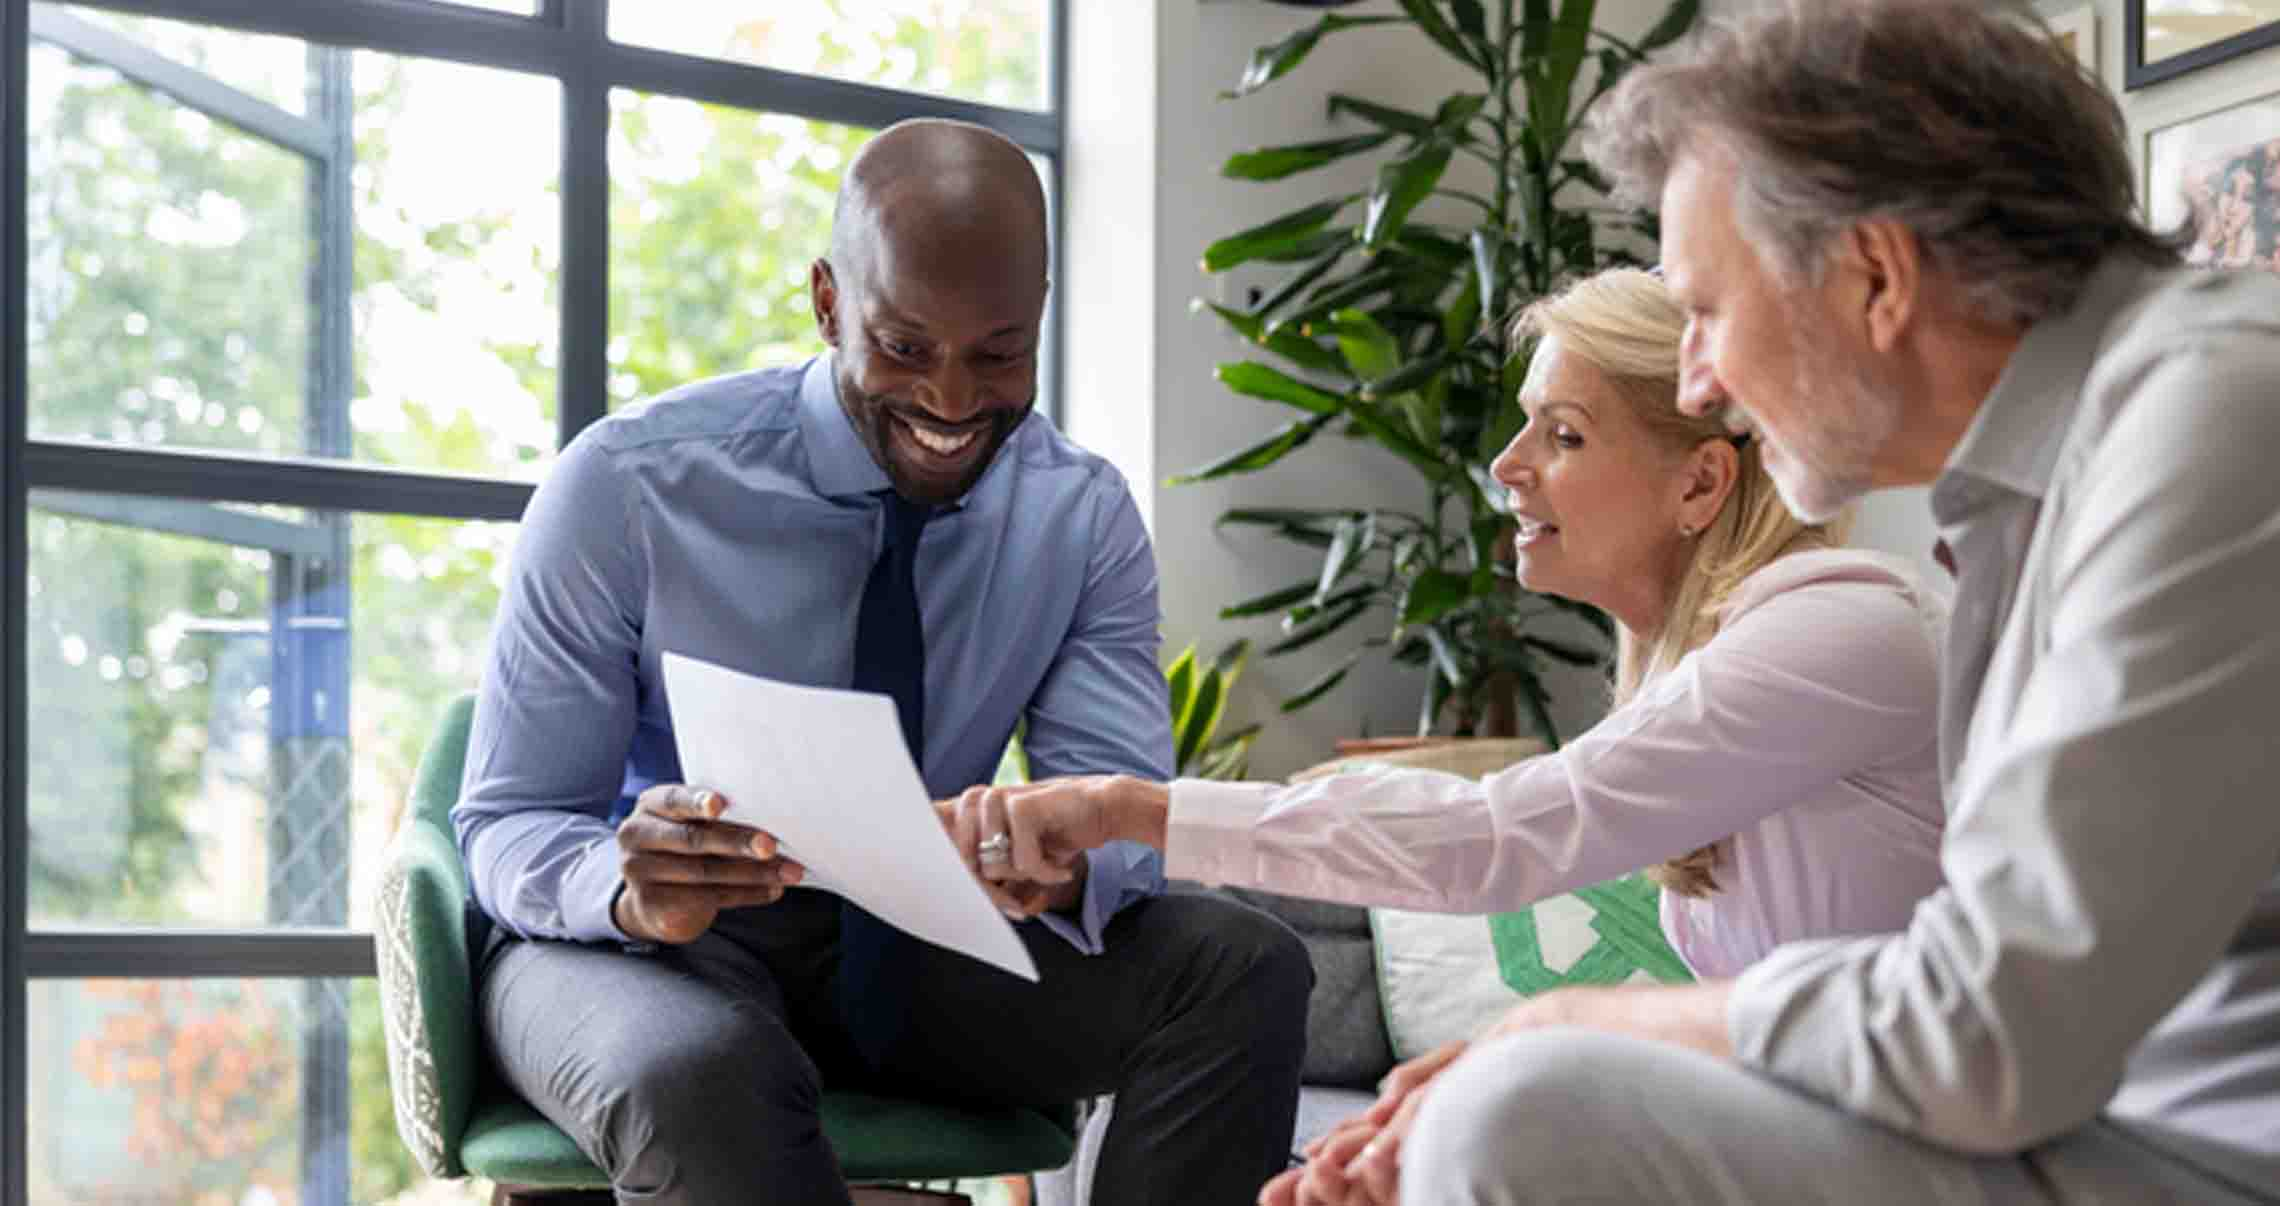

## Business Problem

Banks need to understand customer retirement behavior in order to better plan customer retention strategies and forecast future service demand.

The objective of this project is to build a machine learning model that predicts whether a customer will retire (leave the bank's services) based on demographic and financial information.

### Target Variable

- **Retire**
  - `0` → Customer stays
  - `1` → Customer leaves

### Features

| Feature | Description |
|----------|------------|
| **Customer ID** | Unique customer identifier |
| **Age** | Customer age |
| **401k_savings** | Retirement account savings |

### Machine Learning Task

**Binary Classification**

The model predicts the probability that a customer will retire based on the available customer information.

# Step 1. Import libraries

In [1]:
import time                               # working with time (timing, delays, etc.)
import numpy as np                        # numerical computing and array operations
import pandas as pd                       # working with tabular data (DataFrames)
import scipy.stats as stats               # statistical functions and probability distributions

import matplotlib.pyplot as plt           # basic plotting library
import seaborn as sns                     # statistical data visualization built on top of matplotlib

from sklearn.experimental import enable_iterative_imputer  # enables IterativeImputer (experimental feature)

from sklearn.impute import (
    SimpleImputer,                        # simple imputation (mean/median/most_frequent/constant)
    IterativeImputer,                     # iterative imputation using predictive models
    KNNImputer)                           # imputation based on K-nearest neighbors

from feature_engine.imputation import (
    MeanMedianImputer,                    # replace missing values with mean or median
    RandomSampleImputer,                  # replace missing values with random samples from the feature distribution
    CategoricalImputer)                   # replace missing values in categorical features

from sklearn.preprocessing import (
    StandardScaler,                       # standardization: (x - mean) / std
    MinMaxScaler,                         # scale features to the range [0, 1]
    RobustScaler,                         # robust to outliers (uses median and IQR)
    FunctionTransformer)                  # wrapper for custom transformation functions

import feature_engine.transformation as vt # Yeo-Johnson, Box-Cox, and other distribution transformations

from sklearn.linear_model import (
    LogisticRegression)                   # logistic regression (classification)

from sklearn.tree import DecisionTreeClassifier      # decision tree classifier
from sklearn.neighbors import KNeighborsClassifier   # K-nearest neighbors classifier
from sklearn.svm import SVC                          # support vector classifier
from sklearn.ensemble import RandomForestClassifier  # ensemble-based classifier

from sklearn.metrics import (
    accuracy_score,                       # classification accuracy
    roc_auc_score,                        # area under the ROC curve
    f1_score,                             # F1-score (harmonic mean of precision and recall)
    roc_curve,                            # points for plotting the ROC curve
    confusion_matrix,                     # confusion matrix
    classification_report)                # classification report (precision, recall, F1-score)

from sklearn.model_selection import (
    train_test_split,                     # split data into training and test sets
    GridSearchCV)                         # hyperparameter tuning using Grid Search

from sklearn.pipeline import Pipeline     # machine learning pipeline (sequence of processing steps)

from sklearn.compose import ColumnTransformer # apply different transformations to different columns

In [2]:
# Functions

# Model training and evaluation
def classific_model(model, X, y, X_test,y_test):
    cl_model = model
    cl_model.fit(X, y)
    
    cl_model_pred = cl_model.predict(X_test)
    
    acc_cl_model_train = round(cl_model.score(X, y) * 100, 2)
    acc_cl_model_test = round(cl_model.score(X_test, y_test) *100, 2)
    X_train_proba = cl_model.predict_proba(X)
    X_test_proba = cl_model.predict_proba(X_test)
    print("Train dataset: {}%".format(acc_cl_model_train))
    print("Test dataset: {}%".format(acc_cl_model_test))
    print('Train Set roc-auc:{}'.format(roc_auc_score(y, X_train_proba[:, 1])))
    print('Test Set roc-auc:{}'.format(roc_auc_score(y_test, X_test_proba[:, 1])))

# Missing value imputation
def imputation_function(method, data_train, data_test, columns=None):
    
    data_train_copy = data_train.copy()
    data_test_copy = data_test.copy()

    if columns is None:
        columns = data_train.columns
    
    imputer = method
    imputer.fit(data_train_copy[columns])

    train_transformed = pd.DataFrame(
        imputer.transform(data_train_copy[columns]),
        columns=columns,
        index=data_train_copy.index
    )
    test_transformed = pd.DataFrame(
        imputer.transform(data_test_copy[columns]),
        columns=columns,
        index=data_test_copy.index
    )

    data_train_copy[columns] = train_transformed
    data_test_copy[columns] = test_transformed

    return data_train_copy, data_test_copy

# Feature transformation and model benchmarking
def transformationfordata(trans):
    X_train_trans = trans.fit_transform(X_train)
    X_test_trans = trans.transform(X_test)
    X_train_trans = pd.DataFrame(X_train_trans, columns=X_train.columns)
    X_test_trans = pd.DataFrame(X_test_trans, columns=X_test.columns)
    for var in X_train.columns:
        diagnostic_plots(X_train_trans, var)
        
    print(" Logistic Regression:")
    classific_model(LogisticRegression(random_state=0), 
                    X_train_trans, y_train, 
                    X_test_trans, y_test)
    print("\n Decision Tree:")
    classific_model(DecisionTreeClassifier(random_state=0), 
                    X_train_trans, y_train, 
                    X_test_trans, y_test)

# Distribution diagnostics
def diagnostic_plots(df, variable):
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    df[variable].hist(bins=30)
    plt.title(variable)

    plt.subplot(1,2,2)
    stats.probplot(df[variable], dist='norm', plot=plt)
    plt.title(variable)
    plt.show()

# Feature scaling and benchmarking
def Scalerfordata(namescaler, X_train, X_test, y_train, y_test):
    X_train_imp, X_test_imp = imputation_function(
        MeanMedianImputer(imputation_method='mean'), X_train, X_test
    )

    scaler = namescaler
    scaler.fit(X_train_imp)
    X_train_scaled = pd.DataFrame(scaler.transform(X_train_imp), 
                                  columns=X_train.columns, 
                                  index=X_train.index)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), 
                                 columns=X_test.columns, 
                                 index=X_test.index)

    print(" Logistic Regression:")
    classific_model(LogisticRegression(random_state=0), 
                    X_train_scaled, y_train, 
                    X_test_scaled, y_test)

    print("\n Decision Tree:")
    classific_model(DecisionTreeClassifier(random_state=0), 
                    X_train_scaled, y_train, 
                    X_test_scaled, y_test)

# Model performance evaluation
def Metrics_char(Pipe, X_train, X_test):
    if hasattr(Pipe, "best_estimator_"):
        model = Pipe.best_estimator_
    else:
        model = Pipe

    if hasattr(model, "steps"):  
        model_name = model.steps[-1][1].__class__.__name__
    else: 
        model_name = model.__class__.__name__

    X_train_proba = Pipe.predict_proba(X_train)
    X_test_proba = Pipe.predict_proba(X_test)
    X_train_pred = Pipe.predict(X_train)
    start = time.time()
    X_test_pred = Pipe.predict(X_test)
    predict_time = time.time() - start
    print(f" Время предсказания: {predict_time:.3f} секунд")
    print('Train Set')
    print(f"{model_name} accuracy: {accuracy_score(y_train, X_train_pred):.4f}")
    print('Test Set')
    print(f"{model_name} accuracy: {accuracy_score(y_test, X_test_pred):.4f}")
    print("")
    print('Train Set')
    print(f"{model_name} ROC-AUC: {roc_auc_score(y_train, X_train_proba[:, 1]):.4f}")
    print('Test Set')
    print(f"{model_name} ROC-AUC: {roc_auc_score(y_test, X_test_proba[:, 1]):.4f}")
    print('Train Set')
    print(classification_report(y_train,X_train_pred))
    print('Test Set')
    print(classification_report(y_test, X_test_pred))
    return X_train_proba, X_test_proba,X_train_pred,X_test_pred,predict_time

# Metrics aggregation
def metrics_gridsearch(model_name, y_test, y_train, y_pred_test,y_proba_test,y_pred_train, y_proba_train,predict_time, results_df):

    f1_test = round(f1_score(y_test, y_pred_test), 4)
    acc_test = round(accuracy_score(y_test, y_pred_test), 4)
    roc_test = round(roc_auc_score(y_test, y_proba_test), 4)

    f1_train = round(f1_score(y_train, y_pred_train), 4)
    acc_train = round(accuracy_score(y_train, y_pred_train), 4)
    roc_train = round(roc_auc_score(y_train, y_proba_train), 4)
    results_df[model_name + '_test'] = [f1_test, acc_test, roc_test, predict_time]
    results_df[model_name + '_train'] = [f1_train, acc_train, roc_train, predict_time]
    return results_df

# Confusion matrix visualization    
def plot_custom_confusion_matrix(y_true, y_pred, labels=None, normalize=False, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, normalize='true' if normalize else None)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d",
                cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('False')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ROC curve visualization
def ROC_curve(y_test, X_test_proba):
    fpr, tpr, thresholds = roc_curve(y_test, X_test_proba)
    auc = roc_auc_score(y_test, X_test_proba)
    
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC-curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='random model')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Performance and overfitting analysis
def plot_metrics_overfit_summary(results_df, metrics_list=['Accuracy', 'F1', 'ROC AUC']):
    df = results_df.T
    num_metrics = len(metrics_list)

    fig, axes = plt.subplots(nrows=num_metrics, figsize=(12, 5 * num_metrics))

    if num_metrics == 1:
        axes = [axes]

    for idx, metric_name in enumerate(metrics_list):
        df_metric = df[[metric_name]].copy()
        df_metric['model'] = df_metric.index
        df_metric['type'] = df_metric['model'].apply(lambda x: 'train' if 'train' in x else 'test')
        df_metric['model_clean'] = df_metric['model'].apply(lambda x: x.replace('_train', '').replace('_test', ''))

        pivot = df_metric.pivot(index='model_clean', columns='type', values=metric_name).fillna(0)
        pivot['overfit_%'] = ((pivot['train'] - pivot['test']) / pivot['train']) * 100
        pivot = pivot.sort_values(by='test', ascending=False)

        ax = axes[idx]
        train_bars = ax.barh(pivot.index, pivot['train'], color='orange', label='Train')
        test_bars = ax.barh(pivot.index, pivot['test'], color='steelblue', label='Test')

        for i, model in enumerate(pivot.index):
            train_val = pivot.loc[model, 'train']
            test_val = pivot.loc[model, 'test']
            diff = pivot.loc[model, 'overfit_%']
            ax.text(train_val - 0.01, i - 0.15, f'{train_val*100:.1f}%', color='purple', ha='right', fontsize=11)
            ax.text(test_val - 0.01, i + 0.05, f'{test_val*100:.1f}%', color='blue', ha='right', fontsize=11)
            ax.text(max(train_val, test_val) + 0.01, i, f'{diff:.1f}%', color='darkred', ha='left', va='bottom', fontsize=11)

        ax.set_xlabel(metric_name.upper())
        ax.set_title(f'{metric_name.upper()}: Train vs Test with % Overfitting')
        ax.set_xlim(0, 1.1)
        ax.legend()
        ax.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


    
    test_cols = [col for col in results_df.columns if col.endswith("_test")]
    predict_times_test = results_df.loc["Predict time", test_cols]
    predict_times_test_sorted = predict_times_test.sort_values()
    plt.figure(figsize=(10, 5))
    plt.barh(predict_times_test_sorted.index, predict_times_test_sorted.values, color='seagreen')

    for i, (model, time) in enumerate(predict_times_test_sorted.items()):
        plt.text(time + 0.001, i, f"{time:.4f} s", va='center', fontsize=10)

    plt.xlabel("Prediction Time on Test Set (seconds)")
    plt.title("Prediction Time per Model (Test Only)")
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()


# Step 2. Import libraries

In [137]:
data = pd.read_csv("Bank_Customer_dataset.csv")
data.shape

(500, 4)

In [138]:
data.head()

,Customer ID,Age,401K Savings,Retire
0,0,39.180417,322349.8740,0
1,1,56.101686,768671.5740,1
2,2,57.023043,821505.4718,1
3,3,NaN,494187.4850,0
4,4,54.728823,691435.7723,1


# Step 3 Dataset Analysis

In [139]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Customer ID   500 non-null    int64  
 1   Age           478 non-null    float64
 2   401K Savings  484 non-null    float64
 3   Retire        500 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 15.8 KB


- The target variable is binary.
- **Customer ID** is an identifier (nominal feature) and does not carry predictive information.
- All remaining features are continuous numerical variables.
- The dataset contains missing values that must be handled during the preprocessing stage.

In [140]:
data.describe(include = "all")

,Customer ID,Age,401K Savings,Retire
count,500.000000,478.000000,484.000000,500.000000
mean,249.500000,46.828904,536610.568002,0.500000
std,144.481833,7.834280,187527.555076,0.500501
min,0.000000,25.000000,33837.932150,0.000000
25%,124.750000,41.303515,381909.653150,0.000000
50%,249.500000,46.711140,535544.341550,0.500000
75%,374.250000,52.726929,683034.260050,1.000000
max,499.000000,70.000000,1000000.000000,1.000000


- The mean and median are close for most variables, indicating relatively symmetric distributions and approximate normality.
- **Customer ID** is an identifier rather than a meaningful predictive feature, so it will be excluded from model development.
- **401K Savings** exhibits high variability, suggesting the presence of extreme values (outliers) that may influence model performance.

In [141]:
data = data.drop(['Customer ID'], axis=1)

In [142]:
data.dtypes

Age             float64
401K Savings    float64
Retire            int64
dtype: object

In [143]:
data.shape

(500, 3)

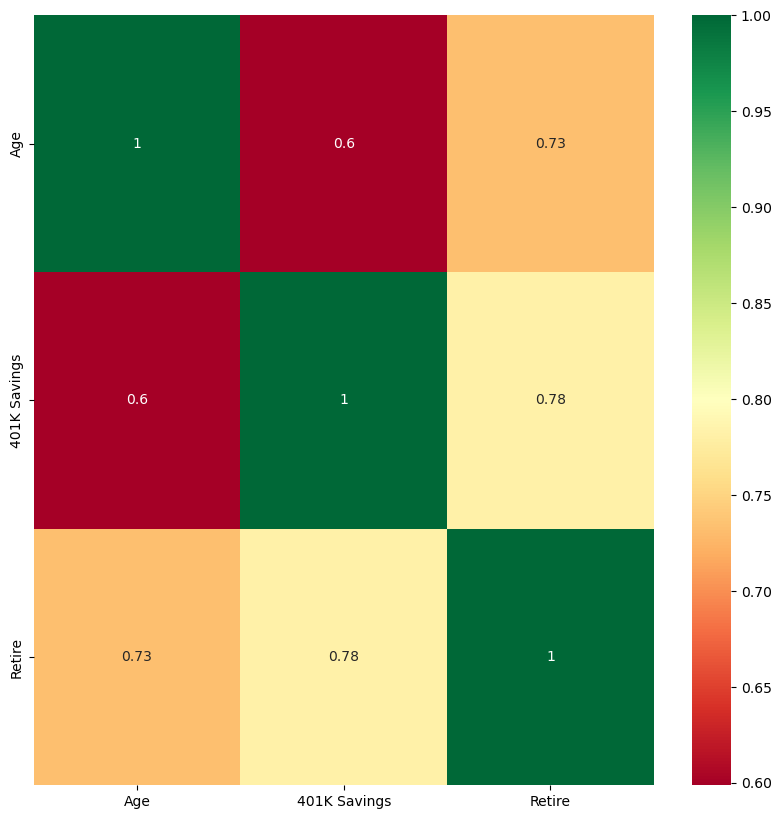

In [14]:
corrMatrix = data.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corrMatrix,cmap="RdYlGn", annot=True)
plt.show()

## Missing values

In [15]:
data.isnull().mean()*100

Age             4.4
401K Savings    3.2
Retire          0.0
dtype: float64

In [16]:
data['age_null'] = np.where(data['Age'].isnull(),1,0)
data.groupby(['Retire'])['age_null'].mean()

Retire
0    0.048
1    0.040
Name: age_null, dtype: float64

In [17]:
data['401K Savings_null'] = np.where(data['401K Savings'].isnull(),1,0)
data.groupby(['Retire'])['401K Savings_null'].mean()

Retire
0    0.028
1    0.036
Name: 401K Savings_null, dtype: float64

<Axes: xlabel='Age', ylabel='401K Savings'>

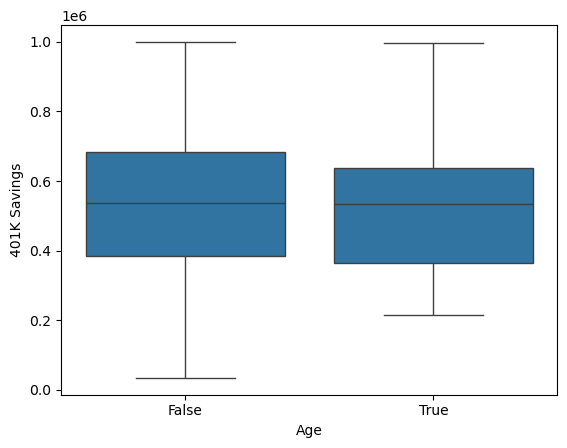

In [18]:
sns.boxplot(x=data["Age"].isnull(), y=data["401K Savings"])

<Axes: xlabel='401K Savings', ylabel='Age'>

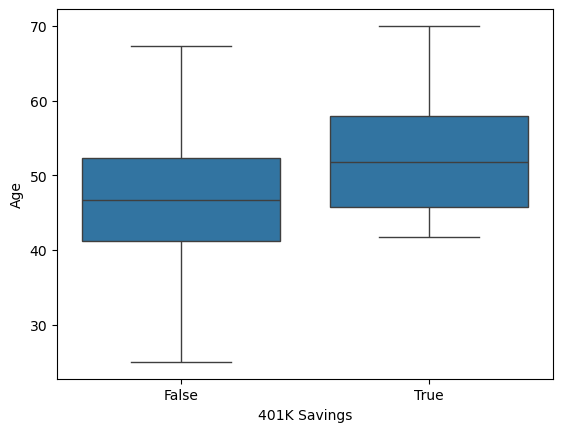

In [19]:
sns.boxplot(x=data["401K Savings"].isnull(), y=data["Age"])

In [20]:
data = data.drop(['401K Savings_null','age_null' ], axis=1)

- Missing values account for approximately **4.4%** of the observations in **Age** and **3.2%** in **401K Savings**.

#### Age

- The distribution of **401K Savings** remains nearly unchanged when comparing missing and non-missing values in **Age**.
- This suggests that the missingness in **Age** is not related to other observed variables.
- Therefore, the missing values in **Age** can be considered **MCAR (Missing Completely At Random)**.

#### 401K Savings

- Missing values in **401K Savings** appear to be associated with **Age**.
- Older customers are more likely to have missing information about their retirement savings.
- This indicates a **MAR (Missing At Random)** mechanism, where missingness depends on another observed feature.

#### Imputation Strategy

- Since **Age** follows an MCAR pattern, simple imputation methods such as mean, median, or random sample imputation are appropriate.
- For **401K Savings**, more advanced techniques that leverage relationships between variables are preferable, such as **IterativeImputer** or **KNNImputer**.

In [21]:
data.shape

(500, 3)

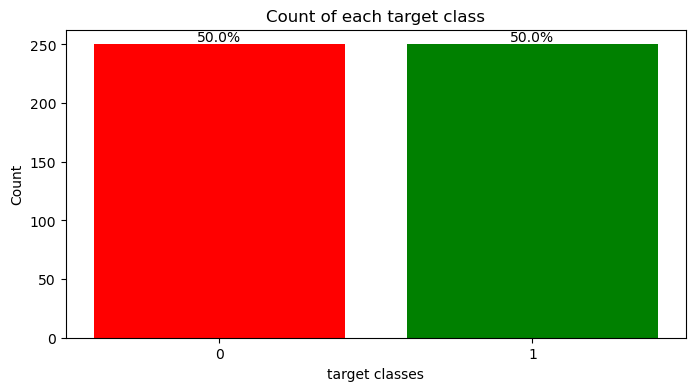

In [22]:
counts = data['Retire'].value_counts().sort_index()
total = counts.sum()
plt.figure(figsize=(8, 4))
bars = plt.bar(counts.index, counts.values, color=['red', 'green'])
plt.xticks(counts.index)
plt.xlabel('target classes')
plt.ylabel('Count')
plt.title('Count of each target class')

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom' 
    )

plt.show()

- The target classes are well balanced, reducing the risk of model bias toward the majority class and making additional resampling techniques unnecessary.
- All predictor variables are numerical. Since no categorical features are present, feature encoding is not required as part of the preprocessing pipeline.

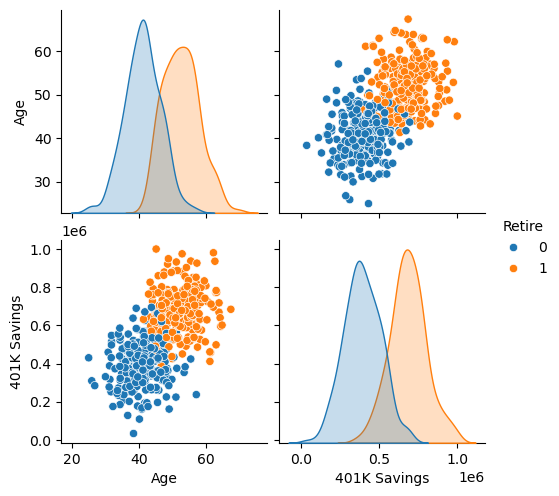

In [23]:
sns.pairplot(data, hue= 'Retire' , vars =['Age','401K Savings'])

- A positive correlation is observed between **Age** and **401K Savings**, indicating that retirement savings tend to increase with age.
- Customers belonging to the positive class (*Retire = 1*) are concentrated in the upper-right region of the plot, suggesting higher ages and larger savings balances.
- This pattern indicates that both **Age** and **401K Savings** may be important predictors of customer retirement behavior.

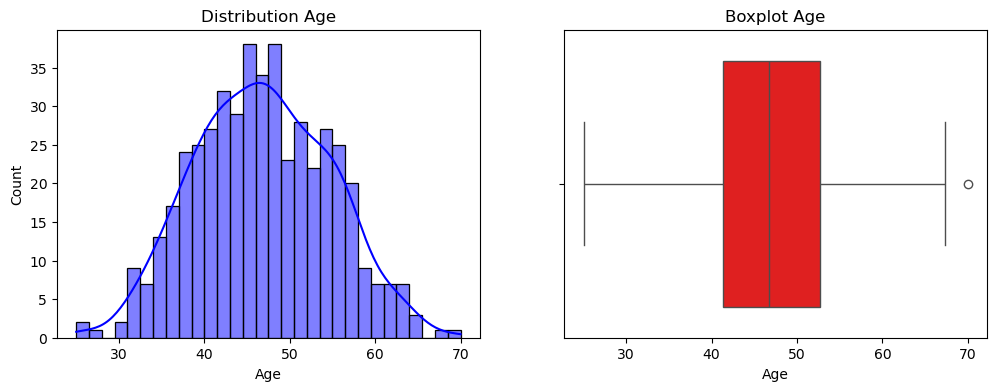

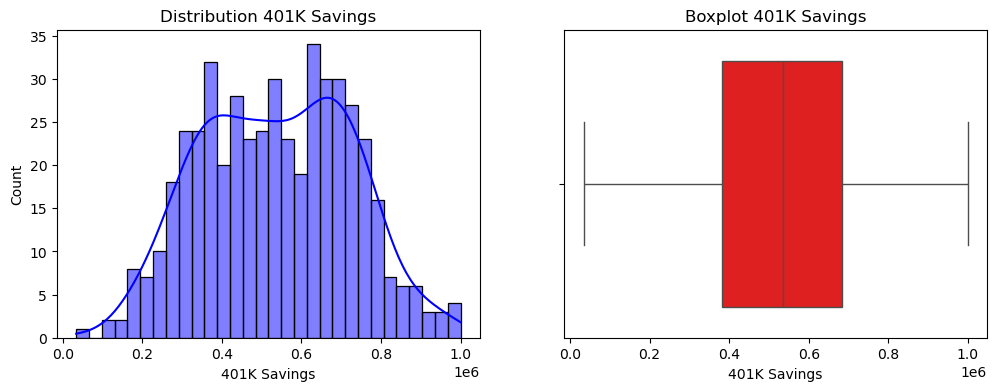

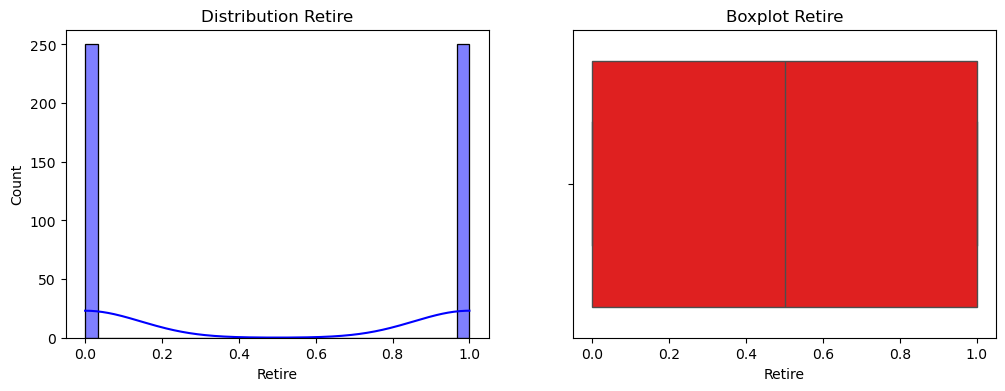

In [24]:
for col in data.columns:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(data[col], kde=True, color='blue', bins=30)
    plt.title(f'Distribution {col}')
    
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col], color='red')
    plt.title(f'Boxplot {col}')
    
    plt.show()

- Most features exhibit approximately normal distributions.
- As a result, standardization is an appropriate scaling technique for the dataset.
- Feature transformation methods will also be evaluated to determine whether they improve the distribution of variables and enhance model performance.

In [25]:
bins = [25, 39, 54, 64, 100]
labels = ['25-39', '40-54', '55-64', '65+']
data['age_group'] = pd.cut(data['Age'], bins=bins, labels=labels, right=True)

age_distribution = data['age_group'].value_counts().sort_index()
print("Customer distribution by age:")
print(age_distribution)

retire_distribution = data.groupby('age_group')['Retire'].mean() * 100
print("\nPercentage of retiring customers by age group:")
print(retire_distribution)

Customer distribution by age:
age_group
25-39     80
40-54    300
55-64     92
65+        5
Name: count, dtype: int64

Percentage of retiring customers by age group:
age_group
25-39      0.000000
40-54     48.333333
55-64     97.826087
65+      100.000000
Name: Retire, dtype: float64


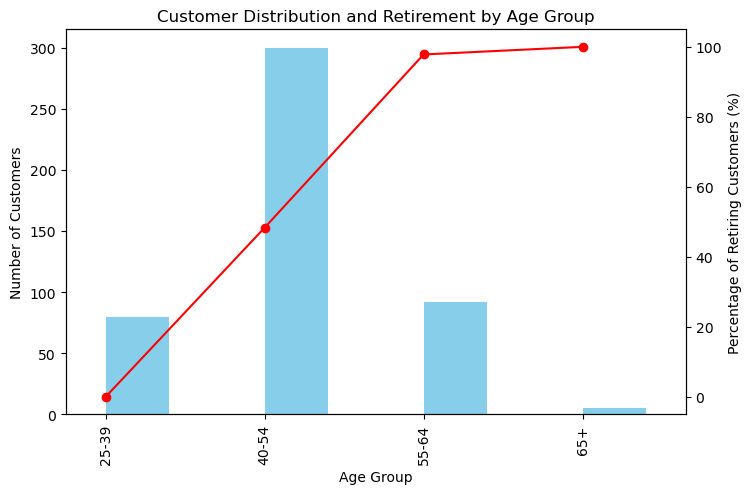

In [26]:
fig, ax1 = plt.subplots(figsize=(8,5))

age_distribution.plot(kind='bar', color='skyblue', ax=ax1, position=0, width=0.4)
ax1.set_ylabel('Number of Customers')
ax1.set_xlabel('Age Group')

ax2 = ax1.twinx()
retire_distribution.plot(kind='line', marker='o', color='red', ax=ax2)
ax2.set_ylabel('Percentage of Retiring Customers (%)')

plt.title('Customer Distribution and Retirement by Age Group')
plt.show()

- The proportion of retired customers increases sharply with age.
- Almost no customers aged 25–39 belong to the retired class.
- Around half of customers aged 40–54 are retired.
- Nearly all customers aged 55 and older belong to the retired class.
- Age demonstrates a strong relationship with retirement status and is likely to be one of the most important predictive features.

                    mean        median           min           max
age_group                                                         
25-39      375648.822292  380482.46690   33837.93215   638074.5123
40-54      538273.973599  536256.51110  109281.63450  1000000.0000
55-64      678952.148238  674958.68540  237410.94740   980549.6557
65+        630273.013825  620835.50285  595089.71060   684331.3390


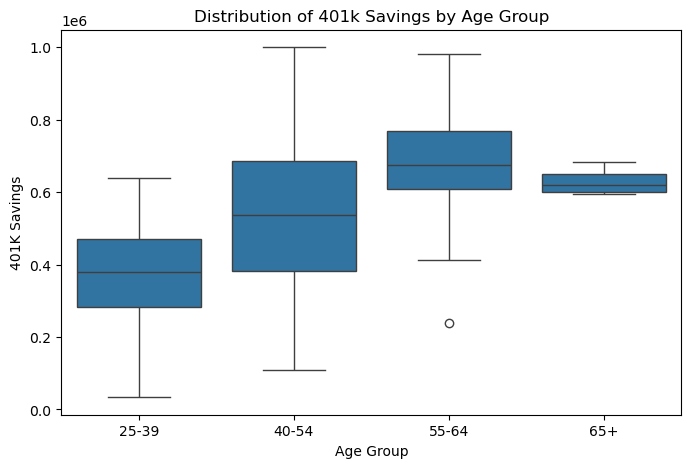

In [29]:
savings_stats = data.groupby('age_group')['401K Savings'].agg(['mean', 'median', 'min', 'max'])
print(savings_stats)

plt.figure(figsize=(8,5))
sns.boxplot(x='age_group', y='401K Savings', data=data)
plt.title("Distribution of 401k Savings by Age Group")
plt.xlabel("Age Group")
plt.ylabel("401K Savings")
plt.show()

                           mean        median           min           max  \
age_group Retire                                                            
25-39     0       375648.822292  380482.46690   33837.93215   638074.5123   
40-54     0       399480.199754  383248.63060  109281.63450   694815.9482   
          1       683909.694043  686070.79210  386341.79630  1000000.0000   
55-64     0       330718.253450  330718.25345  237410.94740   424025.5595   
          1       687145.886939  683098.82890  411502.14230   980549.6557   
65+       1       630273.013825  620835.50285  595089.71060   684331.3390   

                  count  
age_group Retire         
25-39     0          80  
40-54     0         149  
          1         142  
55-64     0           2  
          1          85  
65+       1           4  


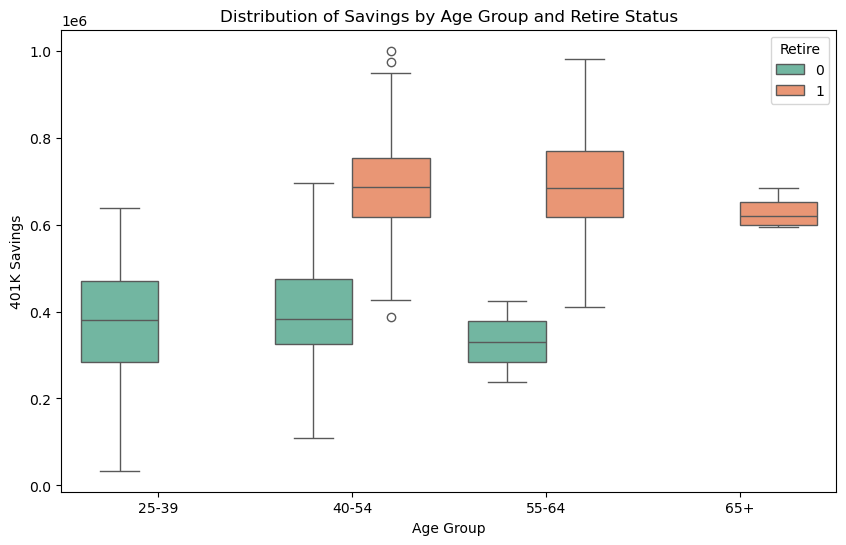

In [30]:
savings_retire_stats = data.groupby(['age_group', 'Retire'])['401K Savings'].agg(['mean', 'median', 'min', 'max', 'count'])
print(savings_retire_stats)

plt.figure(figsize=(10,6))
sns.boxplot(x='age_group', y='401K Savings', hue='Retire', data=data, palette="Set2")
plt.title("Distribution of Savings by Age Group and Retire Status")
plt.xlabel("Age Group")
plt.ylabel("401K Savings")
plt.legend(title="Retire")
plt.show()

1. A higher level of retirement savings is associated with an increased likelihood of retirement.
2. Retirement behavior is concentrated among customers aged 50 and older.
3. Customers over 55 years old are predominantly classified as retired, while customers under 40 are more likely to remain active users of the bank's services.

These findings suggest that both **Age** and **401K Savings** are strong predictors of customer retirement status.

## Conclusion



This dataset contains only two meaningful independent variables and a binary target variable representing whether a customer retires (leaves the bank's services) or remains active.

All predictor variables are numerical and continuous, while categorical features are not present. The dataset is balanced, meaning that both target classes are represented in similar proportions.

Missing values are present in the dataset. During the missing value analysis, it was determined that the missingness mechanism for **Age** is likely **MCAR (Missing Completely At Random)**. Therefore, simple imputation techniques such as mean imputation, median imputation, or Random Sample Imputation are appropriate.

In contrast, missing values in **401K Savings** appear to follow a **MAR (Missing At Random)** pattern and are strongly related to **Age**. As a result, more sophisticated imputation techniques that leverage relationships between variables, such as KNN Imputation or Iterative Imputation, are more suitable.

Exploratory data analysis revealed that retired customers are predominantly of retirement or pre-retirement age. These customers generally have higher retirement savings, while younger customers with lower savings tend to remain active bank clients.

The feature distributions are approximately normal. Therefore, two feature transformation techniques and two scaling methods will be evaluated to determine their impact on model performance.

Feature selection is not required because the dataset contains only a small number of informative predictors.

The following classification algorithms will be used for model development and comparison:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors (KNN)

Model performance will be evaluated using Accuracy, F1-score, ROC-AUC, confusion matrices, and prediction time.

# Step 4. Feature Engineering

In [31]:
data = data.drop(['age_group'], axis=1)

In [32]:
data_for_engin = data.copy()

In [33]:
data_for_engin.shape

(500, 3)

### Missing values

In [34]:
data_for_engin.isnull().mean()

Age             0.044
401K Savings    0.032
Retire          0.000
dtype: float64

In [35]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)

In [36]:
X_train_Random, X_test_Random = imputation_function(RandomSampleImputer(random_state=0), X_train,X_test)

In [37]:
X_train_Random.isna().mean()

Age             0.0
401K Savings    0.0
dtype: float64

In [38]:
#RandomSample
classific_model(LogisticRegression(random_state=0), X_train_Random, y_train,X_test_Random, y_test)

Train dataset: 92.57%
Test dataset: 93.33%
Train Set roc-auc:0.9802941176470588
Test Set roc-auc:0.9848214285714286


In [39]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_Random, y_train,X_test_Random, y_test)

Train dataset: 100.0%
Test dataset: 92.67%
Train Set roc-auc:1.0
Test Set roc-auc:0.9267857142857143


In [40]:
# MEAN
X_train_mean, X_test_mean = imputation_function(MeanMedianImputer(imputation_method='mean'), X_train,X_test)

In [41]:
classific_model(LogisticRegression(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.987516339869281
Test Set roc-auc:0.9898214285714286


In [42]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [43]:
# MEDIAN
X_train_median, X_test_median = imputation_function(MeanMedianImputer(imputation_method='median'), X_train,X_test)

In [44]:
classific_model(LogisticRegression(random_state=0), X_train_median, y_train,X_test_median, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.9871895424836601
Test Set roc-auc:0.9896428571428572


In [45]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_median, y_train,X_test_median, y_test)

Train dataset: 100.0%
Test dataset: 93.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9330357142857144


In [46]:
# K-nn for 401K
imputer = ColumnTransformer(transformers=[
    ("age_median", SimpleImputer(strategy="mean"), ["Age"]),
    ("savings_knn", KNNImputer(n_neighbors=5), ["401K Savings"])
], remainder="passthrough")

imputer.fit(X_train)

X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=imputer.get_feature_names_out())
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out())

In [47]:
classific_model(LogisticRegression(random_state=0), X_train_imp, y_train,X_test_imp, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.987516339869281
Test Set roc-auc:0.9898214285714286


In [48]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_imp, y_train,X_test_imp, y_test)

Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [49]:
imputer = ColumnTransformer(transformers=[
    ("age_median", SimpleImputer(strategy="mean"), ["Age"]),
    ("savings_iter", IterativeImputer(random_state=0), ["401K Savings"])
], remainder="passthrough")

imputer.fit(X_train)

X_train_IT = pd.DataFrame(imputer.transform(X_train), columns=imputer.get_feature_names_out(), index=X_train.index)
X_test_IT = pd.DataFrame(imputer.transform(X_test), columns=imputer.get_feature_names_out(), index=X_test.index)


In [50]:
classific_model(LogisticRegression(random_state=0), X_train_IT, y_train,X_test_IT, y_test)

Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.987516339869281
Test Set roc-auc:0.9898214285714286


In [51]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_IT, y_train,X_test_IT, y_test)

Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [57]:
# Create a new feature to capture the relationship between retirement savings and age
data_for_engin["SavingsPerAge"] = data_for_engin["401K Savings"] / data_for_engin["Age"]

In [58]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)

In [59]:
X_train_mean, X_test_mean = imputation_function(MeanMedianImputer(imputation_method='mean'), X_train,X_test)

In [60]:
classific_model(LogisticRegression(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.988202614379085
Test Set roc-auc:0.9839285714285715


C:\anaconda3\envs\env_for_train\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [56]:
classific_model(DecisionTreeClassifier(random_state=0), X_train_mean, y_train,X_test_mean, y_test)

Train dataset: 100.0%
Test dataset: 96.0%
Train Set roc-auc:1.0
Test Set roc-auc:0.9598214285714286


More sophisticated imputation techniques did not provide a noticeable improvement in model performance. Therefore, mean imputation was selected as the final strategy due to its simplicity and comparable results.

A new feature, **SavingsPerAge**, was created to better capture the relationship between retirement savings and customer age.


## Transformation

In [61]:
TransforData = data.copy()
data.shape

(500, 3)

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    TransforData.drop(['Retire'], axis=1),
    TransforData['Retire'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((350, 2), (150, 2))

In [63]:
X_train, X_test = imputation_function(MeanMedianImputer(imputation_method='mean'), X_train,X_test)

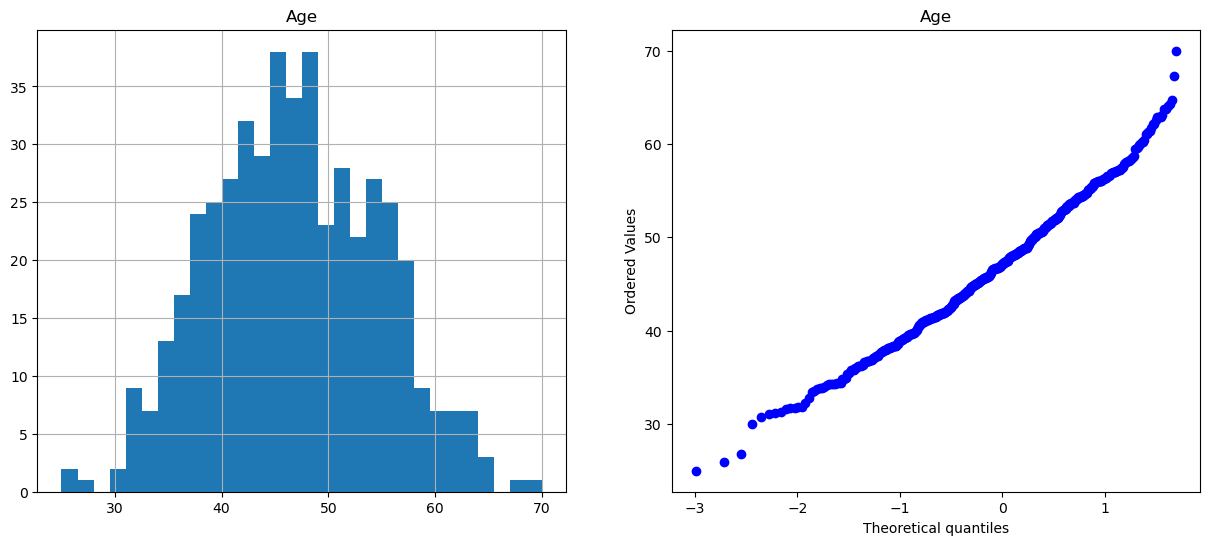

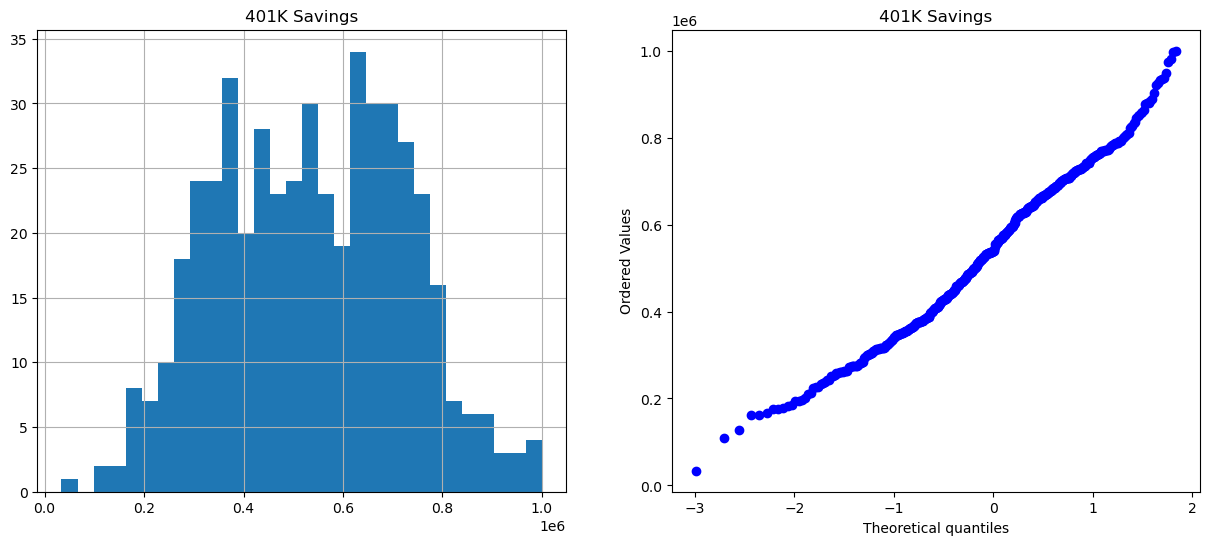

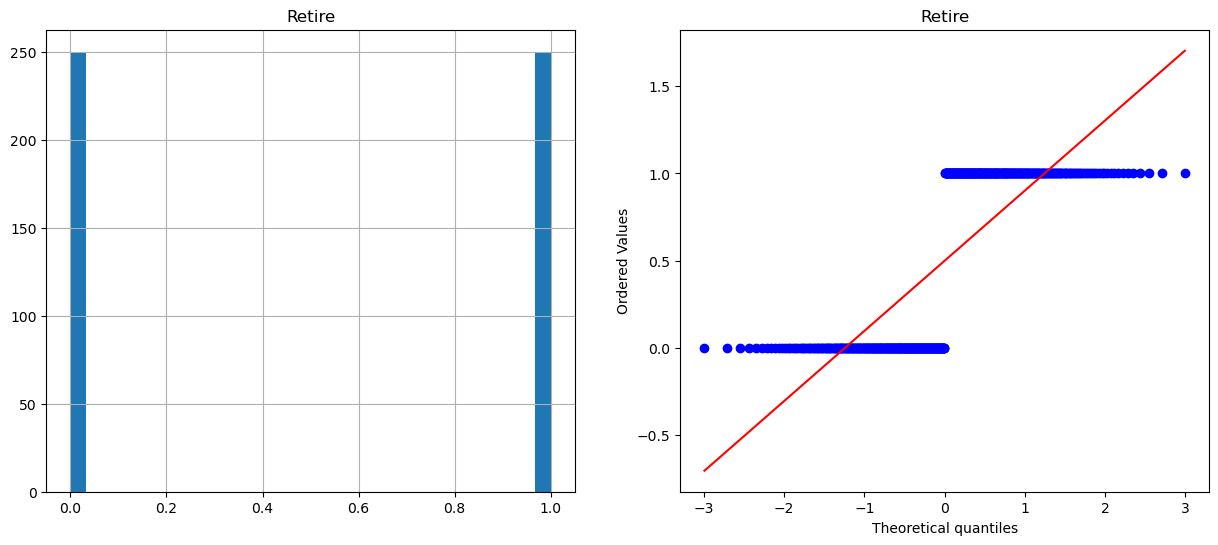

In [64]:
for var in data:
    diagnostic_plots(TransforData, var)

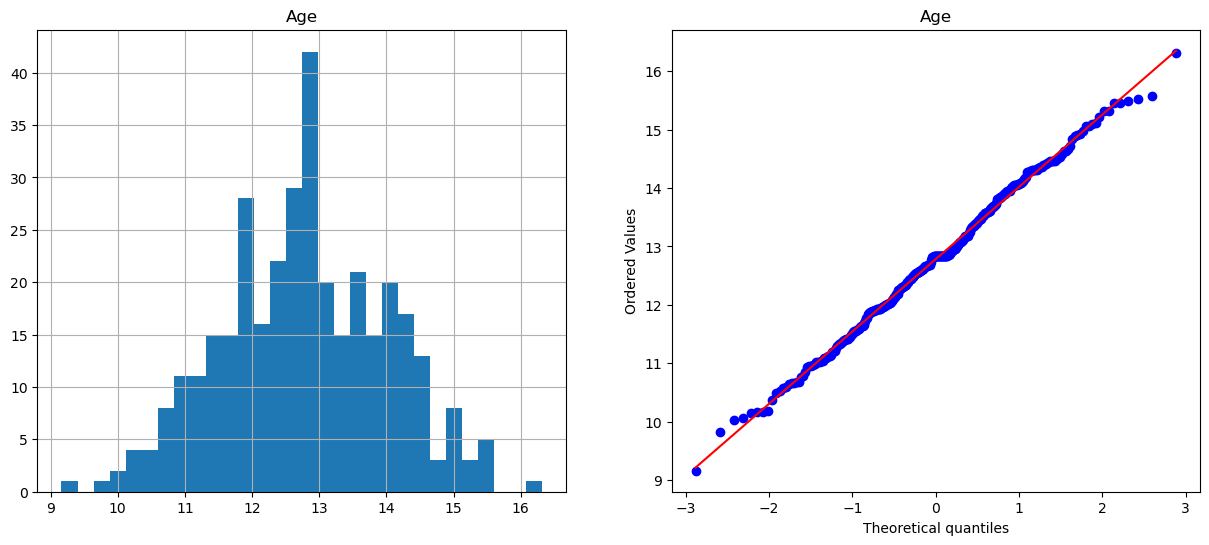

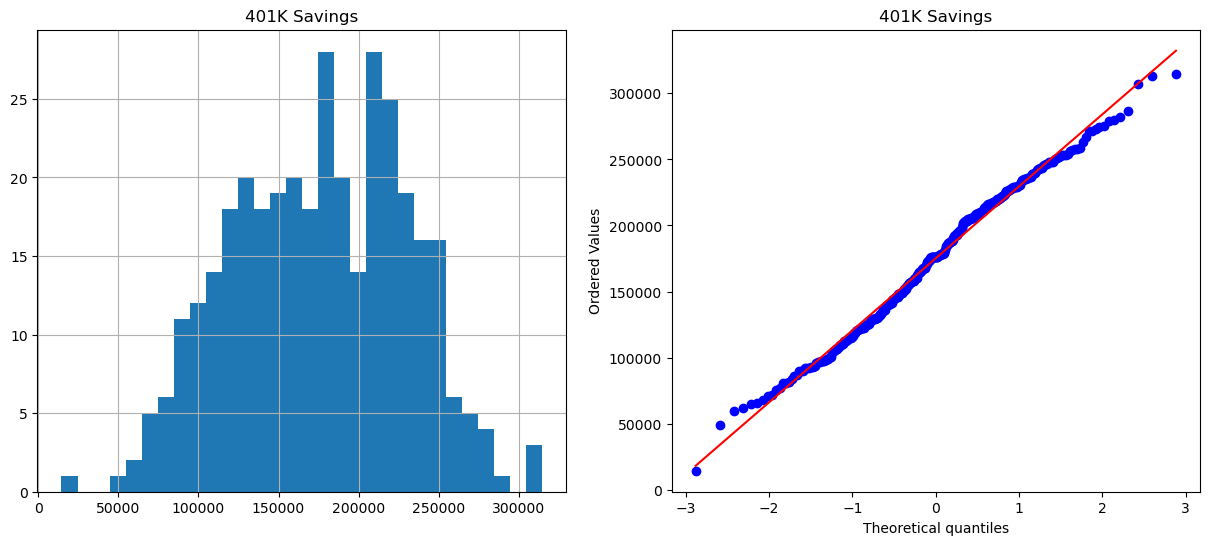

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9871241830065359
Test Set roc-auc:0.9898214285714285

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [65]:
## Yeo-Jojhson
transformationfordata(vt.YeoJohnsonTransformer())

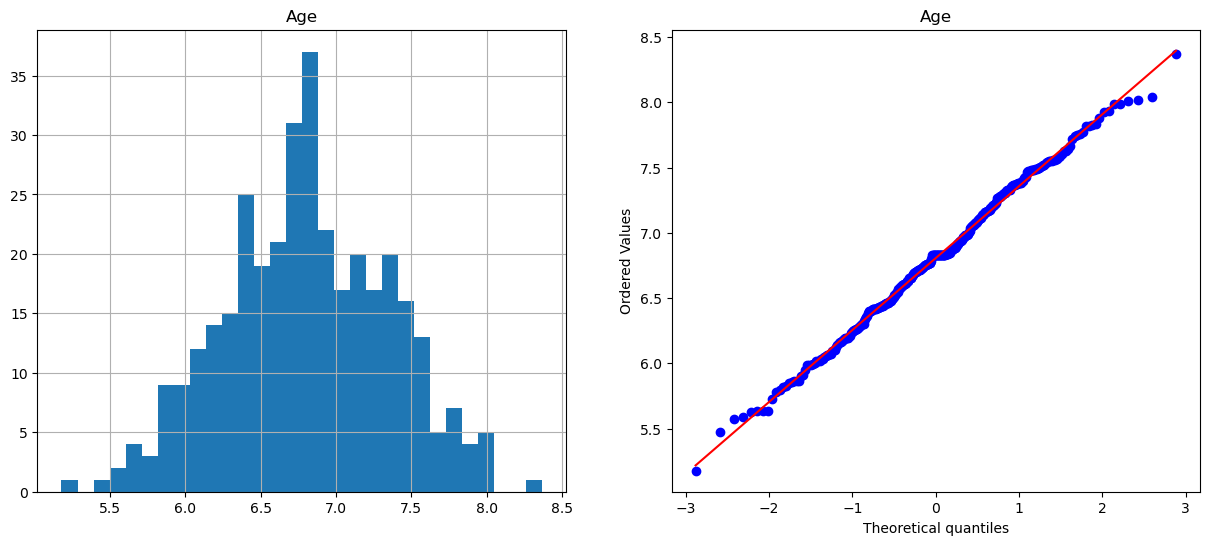

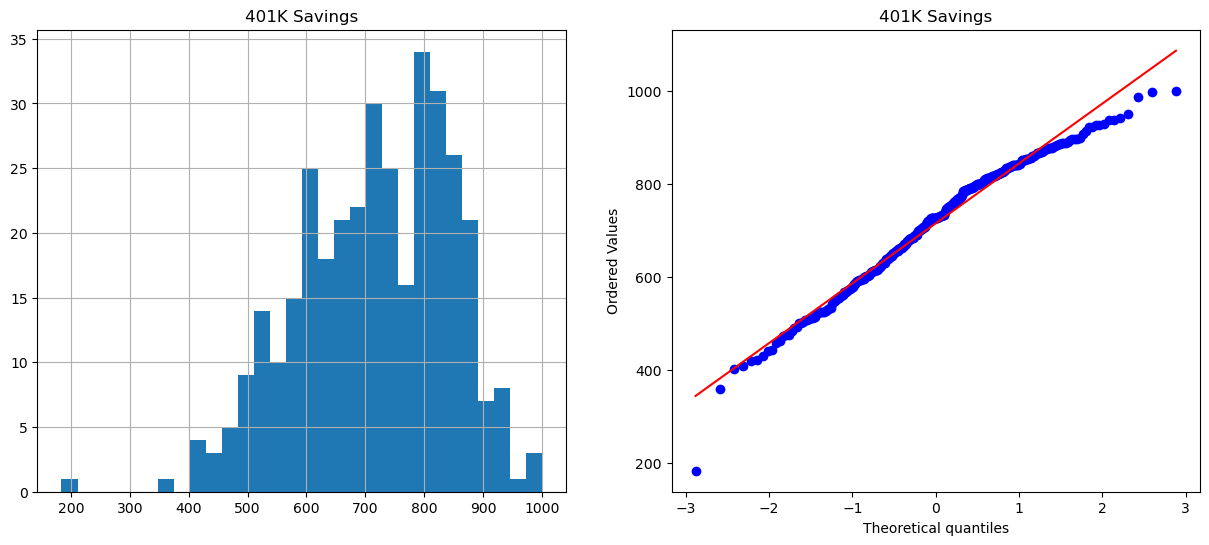

 Logistic Regression:
Train dataset: 94.0%
Test dataset: 95.33%
Train Set roc-auc:0.9862091503267975
Test Set roc-auc:0.9901785714285715

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [66]:
## Exponential
transformationfordata(vt.PowerTransformer())

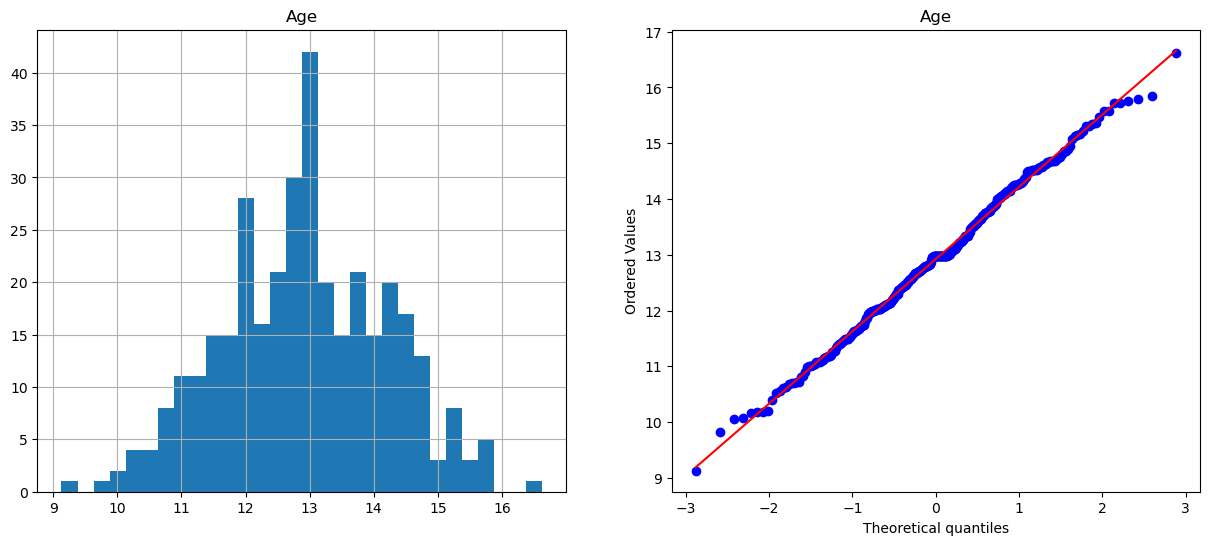

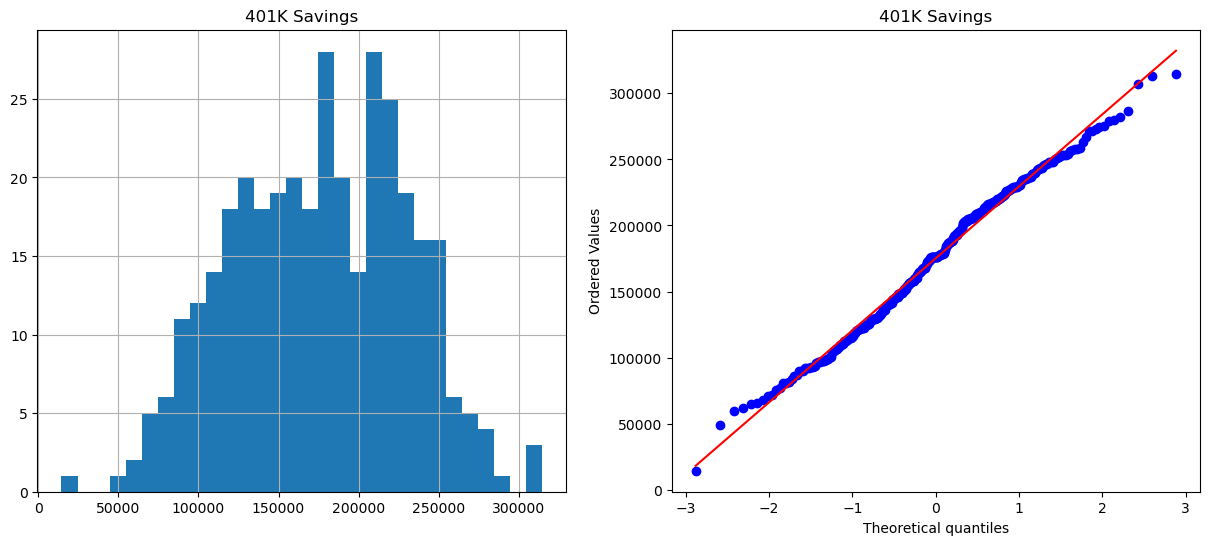

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9870915032679738
Test Set roc-auc:0.9898214285714285

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [67]:
## BoxCox
transformationfordata(vt.BoxCoxTransformer())

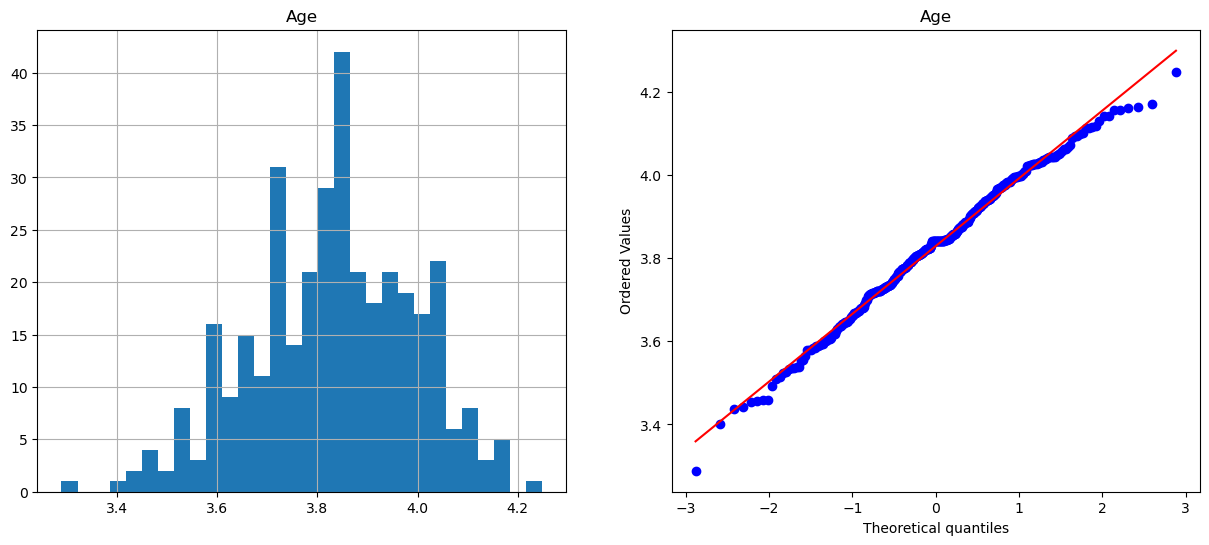

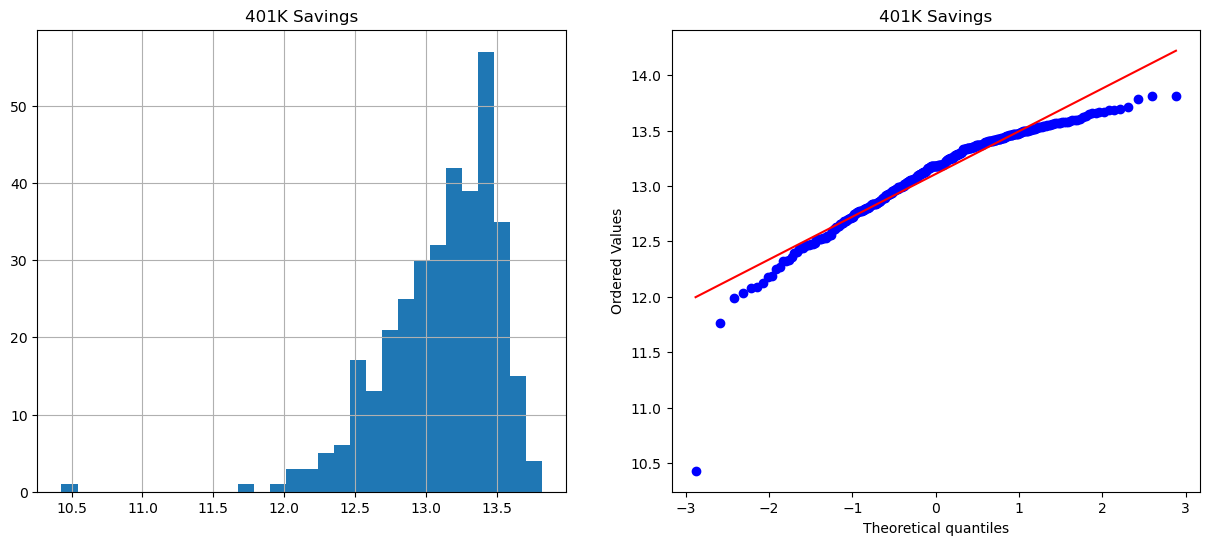

 Logistic Regression:
Train dataset: 93.14%
Test dataset: 95.33%
Train Set roc-auc:0.9819934640522876
Test Set roc-auc:0.9901785714285715

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [68]:
## LogTrans
transformationfordata(vt.LogTransformer())

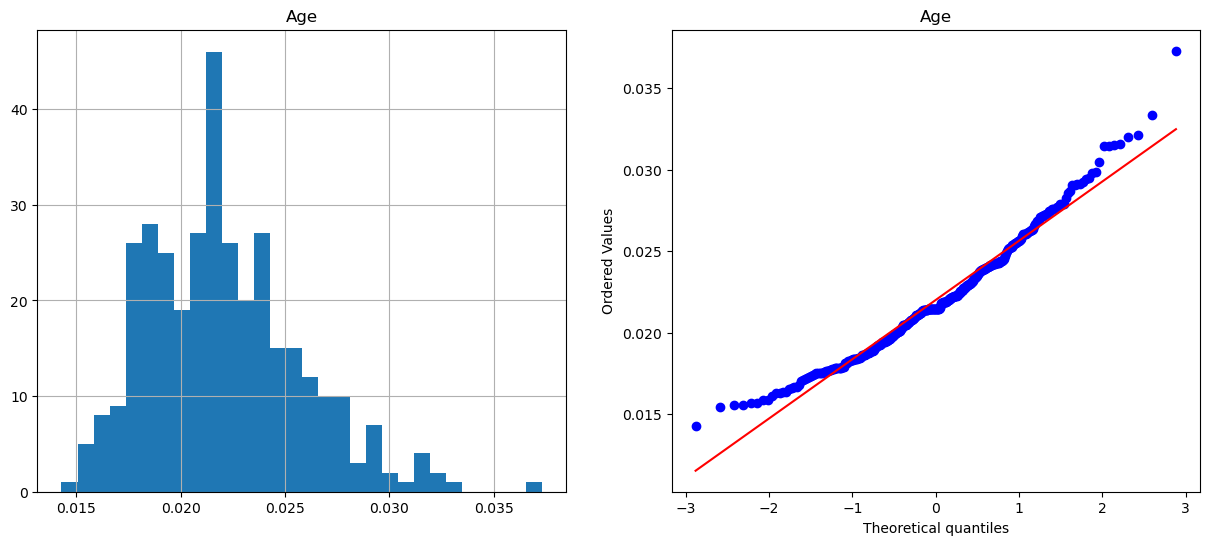

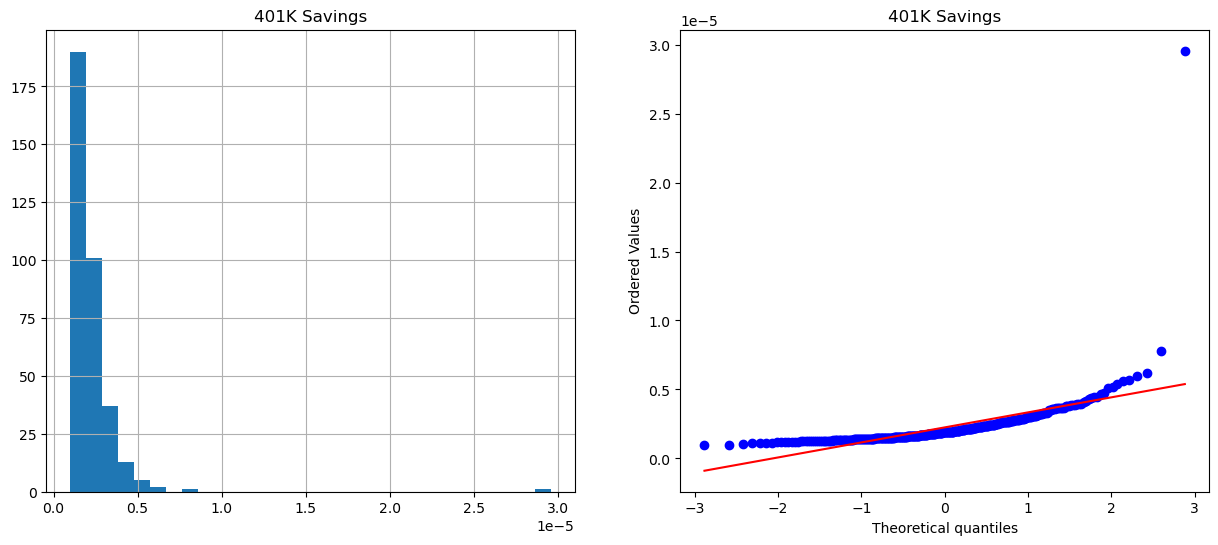

 Logistic Regression:
Train dataset: 51.43%
Test dataset: 46.67%
Train Set roc-auc:0.933562091503268
Test Set roc-auc:0.9260714285714285

 Decision Tree:
Train dataset: 99.43%
Test dataset: 92.0%
Train Set roc-auc:0.9999346405228758
Test Set roc-auc:0.9207142857142857


In [69]:
## Reciprocal
transformationfordata(vt.ReciprocalTransformer())

- Feature transformations did not improve the distributions significantly.
- Model performance either remained unchanged or deteriorated after transformation.
- Therefore, feature transformation was not included in the final preprocessing pipeline.

## Scaling

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    TransforData.drop(['Retire'], axis=1),
    TransforData['Retire'],
    test_size=0.3,
    random_state=0
)

X_train.shape,X_test.shape

((350, 2), (150, 2))

In [71]:
Scalerfordata(RobustScaler(), X_train, X_test, y_train, y_test)

 Logistic Regression:
Train dataset: 94.0%
Test dataset: 94.0%
Train Set roc-auc:0.9874183006535948
Test Set roc-auc:0.99

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [75]:
Scalerfordata(StandardScaler(), X_train, X_test, y_train, y_test)

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9873202614379085
Test Set roc-auc:0.9898214285714285

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


In [77]:
Scalerfordata(MinMaxScaler(), X_train, X_test, y_train, y_test)

 Logistic Regression:
Train dataset: 94.29%
Test dataset: 94.0%
Train Set roc-auc:0.9866013071895424
Test Set roc-auc:0.9901785714285715

 Decision Tree:
Train dataset: 100.0%
Test dataset: 95.33%
Train Set roc-auc:1.0
Test Set roc-auc:0.9535714285714286


### Feature Engineering Conclusions

- Mean imputation achieved the best overall performance and was selected as the final missing value treatment method.
- Feature scaling and transformation techniques did not improve model performance and were therefore excluded from the final pipeline.
- A new feature, **SavingsPerAge**, was introduced to better capture the relationship between customer age and retirement savings.
- The addition of **SavingsPerAge** improved predictive performance, indicating that this engineered feature provides valuable information for the classification task.

# Step 5. Building model

### Baseline model

In [78]:
data_for_engin["SavingsPerAge"] = data_for_engin["401K Savings"] / data_for_engin["Age"]

In [79]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire',"SavingsPerAge" ], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 2), (150, 2))

In [80]:
# zero hypotheses
y_pred_base = np.zeros((len(y_test)))
compare = y_pred_base == y_test
acc_base = sum(compare) / len(compare)
print('Base Line Test Accuracy = ', acc_base)

Base Line Test Accuracy =  0.4666666666666667


In [81]:
baseline = Pipeline(steps = [
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0))
])

In [82]:
baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'mean'
,variables,None
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0


In [83]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(baseline, X_train, X_test)

 Время предсказания: 0.001 секунд
Train Set
LogisticRegression accuracy: 0.9429
Test Set
LogisticRegression accuracy: 0.9400

Train Set
LogisticRegression ROC-AUC: 0.9873
Test Set
LogisticRegression ROC-AUC: 0.9898
Train Set
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       180
           1       0.94      0.95      0.94       170

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

Test Set
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        70
           1       0.96      0.93      0.94        80

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150



In [84]:
results = pd.DataFrame(columns=['F1', 'Accuracy', 'ROC AUC', 'Predict time']).T

In [85]:
results = metrics_gridsearch ("baseline_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

In [86]:
results

,baseline_model_test,baseline_model_train
F1,0.9427,0.9415
Accuracy,0.9400,0.9429
ROC AUC,0.9898,0.9873
Predict time,0.0010,0.0010


### Logistic regression

In [87]:
X_train,X_test, y_train, y_test = train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 3), (150, 3))

In [88]:
Logitpipe = Pipeline(steps = [
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('transformer', vt.BoxCoxTransformer()),
    ('scaler', StandardScaler()),
    ('Logit', LogisticRegression(random_state=0))
])

In [89]:
Logit_param_grid = {
    'transformer':[vt.BoxCoxTransformer(),vt.YeoJohnsonTransformer()],
    'scaler': [StandardScaler(), MinMaxScaler()],
    'Logit__C': [0.05, 0.1,0.2],
    'Logit__max_iter': [5,7,10]}

In [90]:
Logit_grid_search = GridSearchCV(estimator=Logitpipe, param_grid=Logit_param_grid, cv=5, n_jobs=-1, scoring='accuracy', error_score='raise')

In [91]:
LOGIT_MODEL = Logit_grid_search.fit(X_train, y_train)

C:\anaconda3\envs\env_for_train\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [92]:
LOGIT_MODEL.best_params_

{'Logit__C': 0.1,
 'Logit__max_iter': 5,
 'scaler': StandardScaler(),
 'transformer': BoxCoxTransformer()}

In [93]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(LOGIT_MODEL, X_train, X_test)

 Время предсказания: 0.003 секунд
Train Set
LogisticRegression accuracy: 0.9400
Test Set
LogisticRegression accuracy: 0.9467

Train Set
LogisticRegression ROC-AUC: 0.9857
Test Set
LogisticRegression ROC-AUC: 0.9918
Train Set
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       180
           1       0.93      0.95      0.94       170

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        70
           1       0.96      0.94      0.95        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



In [94]:
results = metrics_gridsearch ("Logit_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

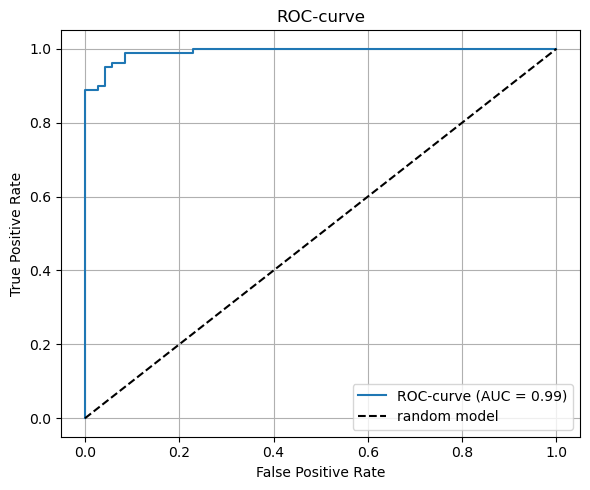

In [95]:
ROC_curve(y_test,X_test_proba[:, 1])

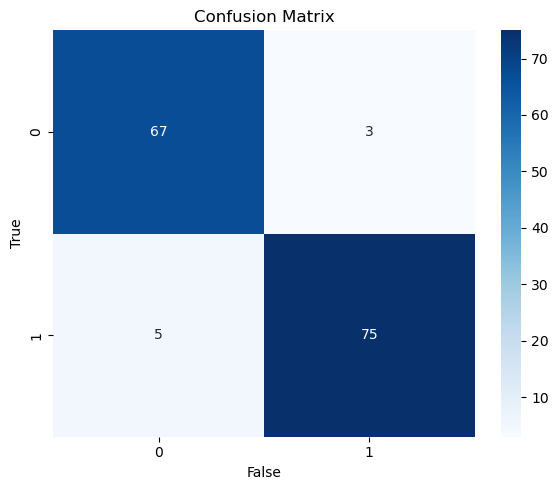

In [96]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False,)

### Decision Tree

In [97]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire',"SavingsPerAge"], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 2), (150, 2))

In [98]:
DT_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    #('transformer', vt.YeoJohnsonTransformer()),
    ('model', DecisionTreeClassifier(random_state=0))
])

In [99]:
DT_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'mean'
,variables,None
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [100]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(DT_pipeline, X_train, X_test)

 Время предсказания: 0.001 секунд
Train Set
DecisionTreeClassifier accuracy: 1.0000
Test Set
DecisionTreeClassifier accuracy: 0.9533

Train Set
DecisionTreeClassifier ROC-AUC: 1.0000
Test Set
DecisionTreeClassifier ROC-AUC: 0.9536
Train Set
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       180
           1       1.00      1.00      1.00       170

    accuracy                           1.00       350
   macro avg       1.00      1.00      1.00       350
weighted avg       1.00      1.00      1.00       350

Test Set
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        70
           1       0.96      0.95      0.96        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



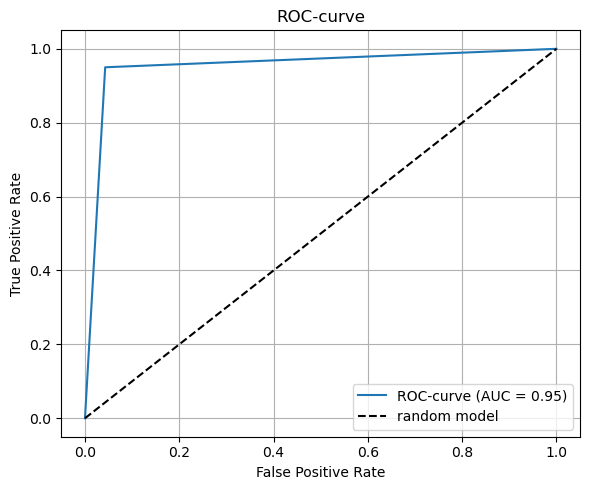

In [101]:
ROC_curve(y_test,X_test_proba[:, 1])

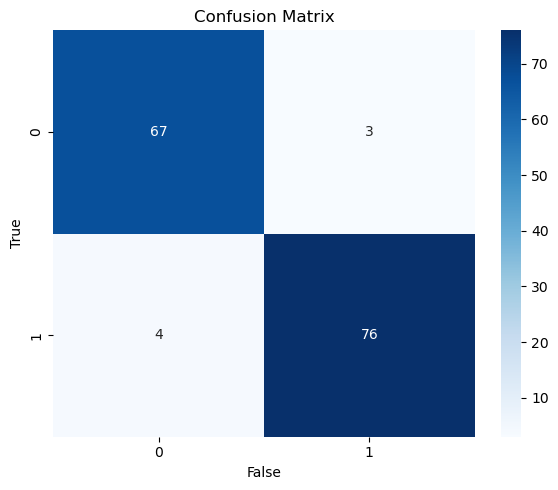

In [102]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [103]:
DT_param_grid = {
    'model__max_depth': [4,5],
    'model__min_samples_leaf': [6,7,8],
    'model__min_samples_split': [5,6]}

In [104]:
DT_grid_search = GridSearchCV(estimator=DT_pipeline, param_grid=DT_param_grid, cv=5, n_jobs=-1, scoring='accuracy', error_score='raise')

In [105]:
DT_MODEL = DT_grid_search.fit(X_train, y_train)

In [106]:
DT_MODEL.best_params_

{'model__max_depth': 4,
 'model__min_samples_leaf': 6,
 'model__min_samples_split': 5}

In [107]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(DT_MODEL, X_train, X_test)

 Время предсказания: 0.001 секунд
Train Set
DecisionTreeClassifier accuracy: 0.9543
Test Set
DecisionTreeClassifier accuracy: 0.9533

Train Set
DecisionTreeClassifier ROC-AUC: 0.9922
Test Set
DecisionTreeClassifier ROC-AUC: 0.9851
Train Set
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       180
           1       0.96      0.94      0.95       170

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.97      0.94      0.96        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



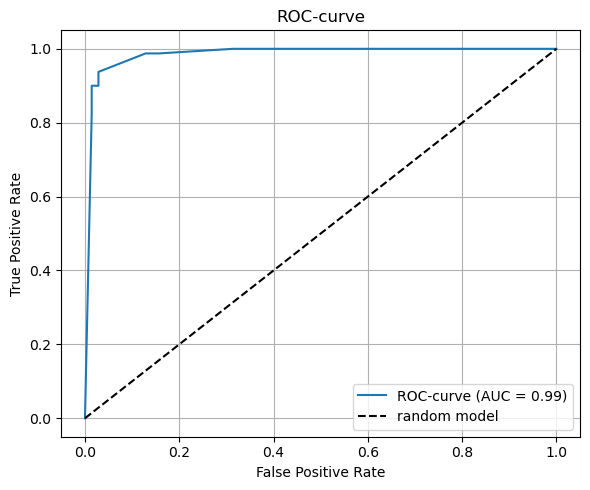

In [108]:
ROC_curve(y_test,X_test_proba[:, 1])

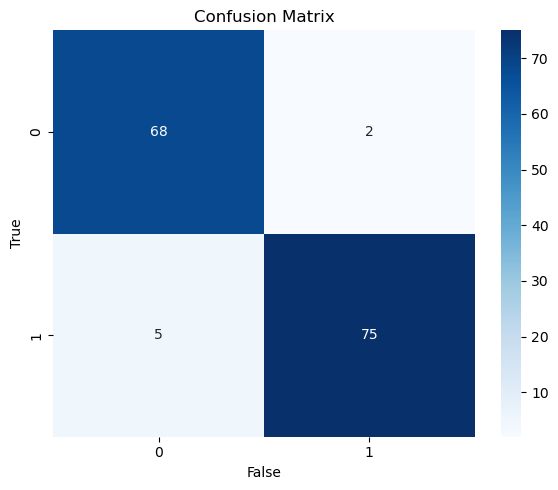

In [109]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [110]:
results = metrics_gridsearch ("DecisionTree_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

In [111]:
results

,baseline_model_test,baseline_model_train,Logit_model_test,Logit_model_train,DecisionTree_model_test,DecisionTree_model_train
F1,0.9427,0.9415,0.949400,0.938800,0.9554,0.9524
Accuracy,0.9400,0.9429,0.946700,0.940000,0.9533,0.9543
ROC AUC,0.9898,0.9873,0.991800,0.985700,0.9851,0.9922
Predict time,0.0010,0.0010,0.003001,0.003001,0.0010,0.0010


### K-nn model

In [112]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire',"SavingsPerAge"], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 2), (150, 2))

In [113]:
KNN_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    #('transformer', vt.YeoJohnsonTransformer()),
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=6))
])

In [114]:
KNN_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'mean'
,variables,None
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'


In [115]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(KNN_pipeline, X_train, X_test)

 Время предсказания: 0.003 секунд
Train Set
KNeighborsClassifier accuracy: 0.9457
Test Set
KNeighborsClassifier accuracy: 0.9467

Train Set
KNeighborsClassifier ROC-AUC: 0.9917
Test Set
KNeighborsClassifier ROC-AUC: 0.9802
Train Set
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       180
           1       0.95      0.94      0.94       170

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        70
           1       0.96      0.94      0.95        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



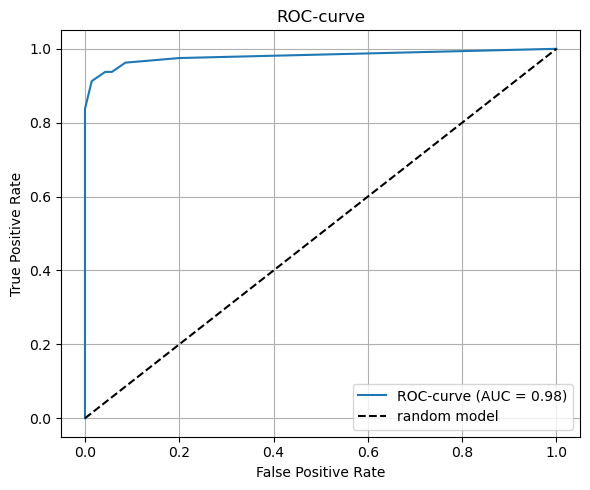

In [116]:
ROC_curve(y_test,X_test_proba[:, 1])

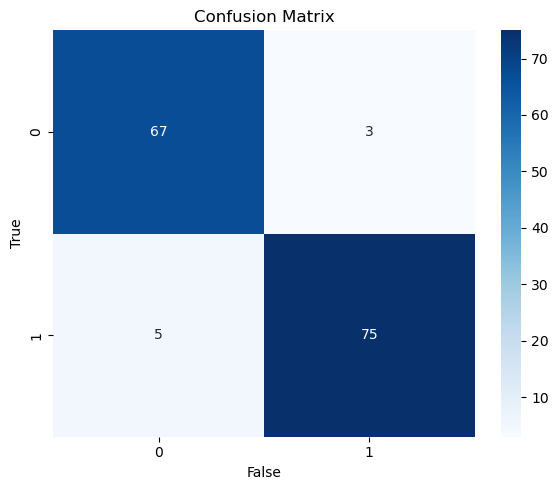

In [117]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [118]:
results = metrics_gridsearch ("Knn_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

### SVM model

In [119]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 3), (150, 3))

In [120]:
SVC_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('transformer', vt.YeoJohnsonTransformer()),
    ('scaler', StandardScaler()),
    ('model', SVC(C=0.3, kernel='linear', random_state=0,probability=True))
])

In [121]:
SVC_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'mean'
,variables,None
,variables,None
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.3


In [122]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred, predict_time = Metrics_char(SVC_pipeline, X_train, X_test)

 Время предсказания: 0.003 секунд
Train Set
SVC accuracy: 0.9429
Test Set
SVC accuracy: 0.9400

Train Set
SVC ROC-AUC: 0.9873
Test Set
SVC ROC-AUC: 0.9898
Train Set
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       180
           1       0.94      0.95      0.94       170

    accuracy                           0.94       350
   macro avg       0.94      0.94      0.94       350
weighted avg       0.94      0.94      0.94       350

Test Set
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        70
           1       0.96      0.93      0.94        80

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150



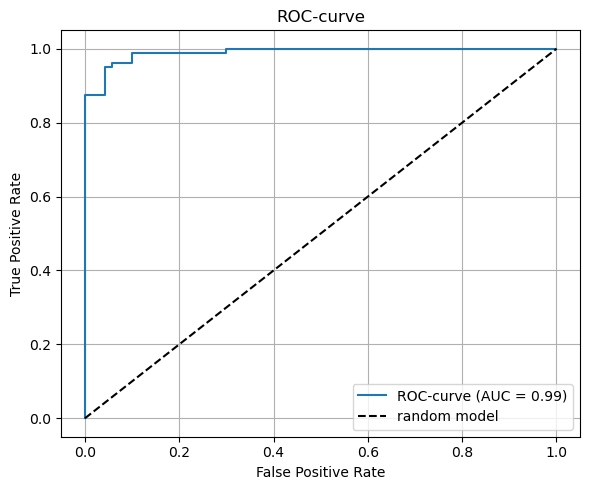

In [123]:
ROC_curve(y_test,X_test_proba[:, 1])

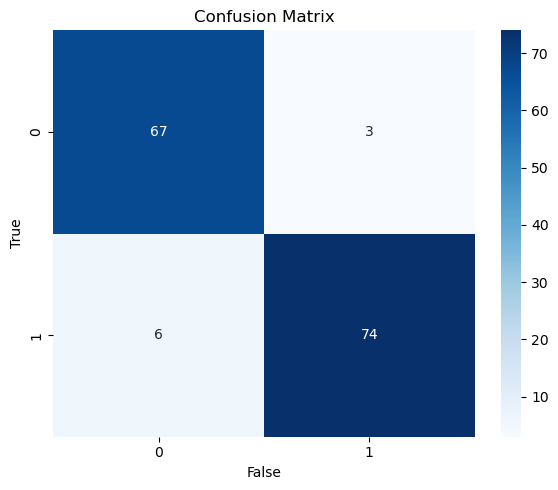

In [124]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [125]:
results = metrics_gridsearch ("SVC_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

### Random Forest

In [126]:
X_train,X_test, y_train, y_test  =train_test_split(
    data_for_engin.drop(['Retire'], axis=1),
    data_for_engin['Retire'], 
    random_state = 0,
    test_size=0.3
)
X_train.shape, X_test.shape

((350, 3), (150, 3))

In [127]:
RF_pipeline = Pipeline(steps=[
    ('imputer', MeanMedianImputer(imputation_method='mean')),
    ('transformer', vt.YeoJohnsonTransformer()),
    #('scaler', StandardScaler()),
    ('model', RandomForestClassifier(max_depth=3,n_estimators=60, random_state=0))
])

In [128]:
RF_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('transformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,imputation_method,'mean'
,variables,None
,variables,None
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",60
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [129]:
X_train_proba, X_test_proba,X_train_pred,X_test_pred,predict_time = Metrics_char(RF_pipeline, X_train, X_test)

 Время предсказания: 0.004 секунд
Train Set
RandomForestClassifier accuracy: 0.9543
Test Set
RandomForestClassifier accuracy: 0.9533

Train Set
RandomForestClassifier ROC-AUC: 0.9895
Test Set
RandomForestClassifier ROC-AUC: 0.9904
Train Set
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       180
           1       0.96      0.94      0.95       170

    accuracy                           0.95       350
   macro avg       0.95      0.95      0.95       350
weighted avg       0.95      0.95      0.95       350

Test Set
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        70
           1       0.97      0.94      0.96        80

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150



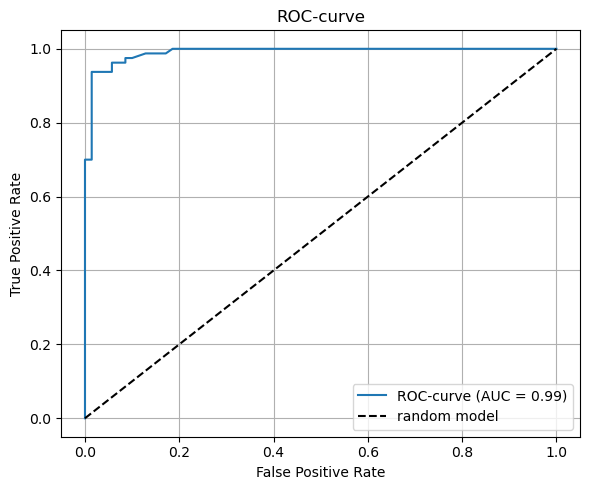

In [130]:
ROC_curve(y_test,X_test_proba[:, 1])

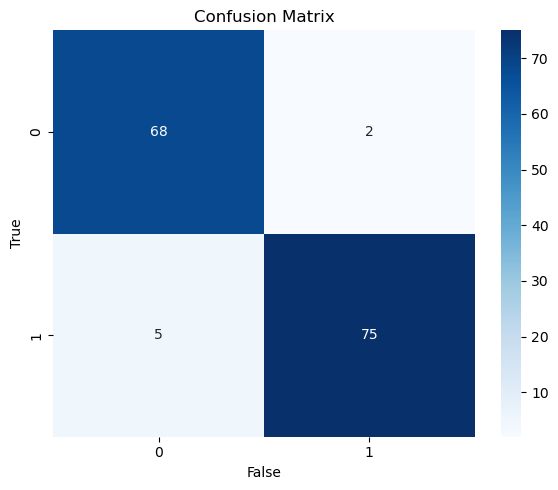

In [131]:
plot_custom_confusion_matrix(y_test, X_test_pred,labels=[0, 1], normalize=False)

In [132]:
results = metrics_gridsearch ("RandomForest_model", y_test, y_train, X_test_pred, X_test_proba[:, 1], X_train_pred, X_train_proba[:, 1],predict_time, results)

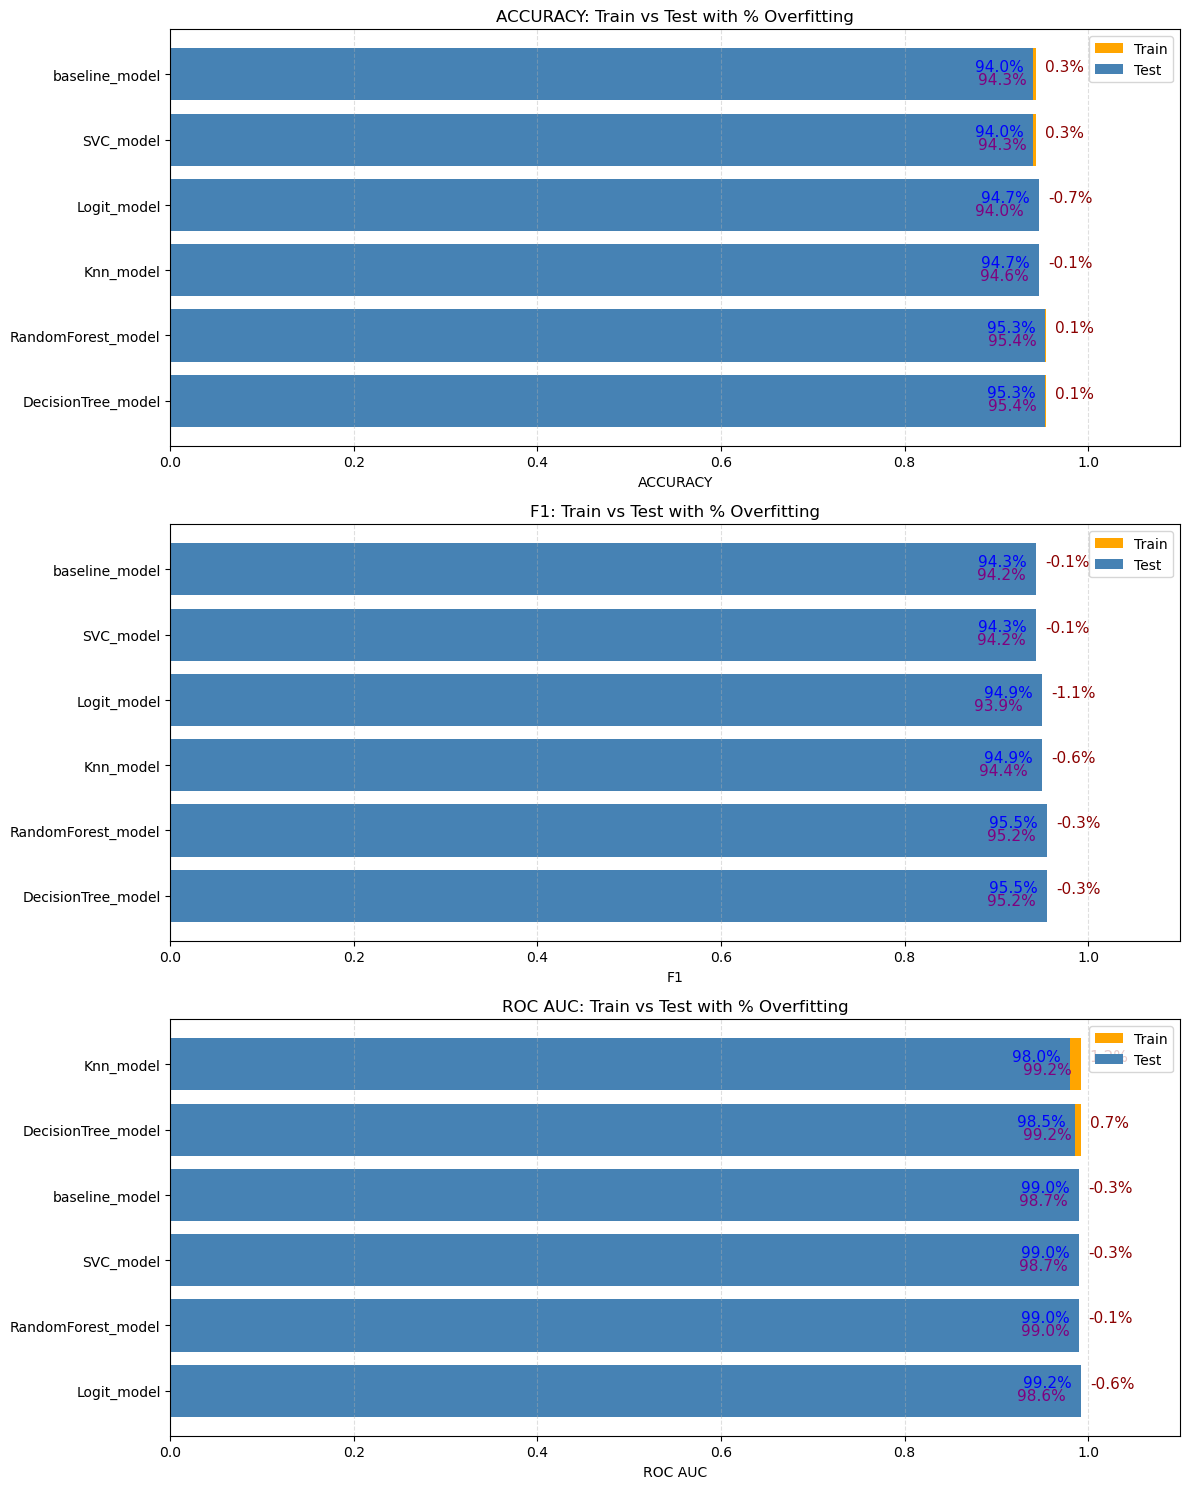

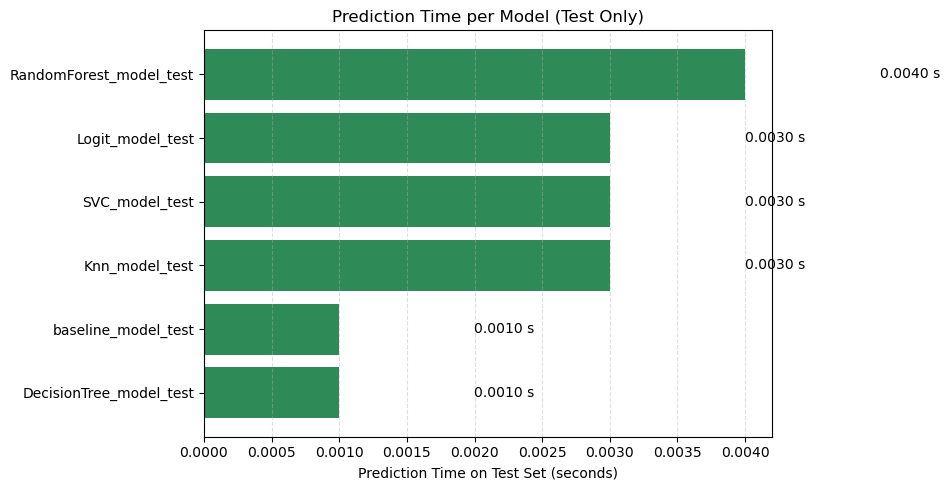

In [133]:
plot_metrics_overfit_summary(results, metrics_list=['Accuracy', 'F1', 'ROC AUC'])

## Conclusion

Several machine learning models were evaluated for predicting customer retirement behavior. All models achieved strong performance, demonstrating high Accuracy, F1-score, and ROC-AUC values with minimal differences between training and test results, indicating good generalization and no significant overfitting.

Feature engineering contributed to model improvement. The engineered feature **SavingsPerAge** enhanced the relationship between age and retirement savings and improved performance metrics for several models.

The analysis showed that advanced preprocessing techniques, including complex imputation methods, feature transformations, and feature scaling, did not provide meaningful performance gains. Therefore, a simpler preprocessing strategy was selected.

Although the dataset contains only a small number of informative features, the models achieved excellent predictive performance, with the highest test accuracy reaching approximately **95.4%**.

Among the evaluated algorithms, **Decision Tree** delivered the strongest overall performance, achieving the highest Accuracy and F1-score while maintaining excellent ROC-AUC and showing virtually no signs of overfitting. As a result, it was selected as the final model for this project.

This project demonstrates a complete machine learning workflow, including exploratory data analysis, missing value treatment, feature engineering, preprocessing evaluation, model comparison, and final model selection.